# Project 2: EDA Analysis for Store Benchmarking and Recommendation System

## Objectives
Conduct exploratory data analysis for store clustering and recommendation system development, identifying key features and patterns.

## Analysis Framework
1. **Data Overview and Quality Check**
2. **Feature Distribution Analysis** - Preparation for clustering
3. **Performance Benchmarking** - Identify high/low performers
4. **Correlation Analysis** - Identify key driving factors
5. **Time Series Patterns** - Seasonality and trend analysis
6. **Store Clustering Preparation** - Feature engineering and selection


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Data Loading and Overview


In [2]:
# Load processed data
df_monthly = pd.read_csv('../data/processed/store_kpi_clean.csv')
df_stores = pd.read_csv('../data/processed/store_features.csv')

print("=== Data Loading Complete ===")
print(f"Monthly data (store_kpi_clean): {df_monthly.shape}")
print(f"Store features (store_features): {df_stores.shape}")

# Convert month to datetime
df_monthly['month'] = pd.to_datetime(df_monthly['month'])

print(f"\nTime range: {df_monthly['month'].min()} to {df_monthly['month'].max()}")
print(f"Unique store count: {df_monthly['store_id'].nunique()}")
print(f"Data completeness: {df_monthly.isnull().sum().sum()} missing values")


=== Data Loading Complete ===
Monthly data (store_kpi_clean): (61322, 66)
Store features (store_features): (2557, 31)

Time range: 2023-10-01 00:00:00+00:00 to 2025-09-01 00:00:00+00:00
Unique store count: 2557
Data completeness: 0 missing values


## 2. Key Metrics Distribution Analysis


In [3]:
# Key metrics analysis - using correct column names
key_metrics = ['sales_mean', 'total_ad_spend_mean', 'website_visits_mean', 'unique_lead_count_mean', 
               'ctr_clean_mean', 'conversion_rate_mean', 'roas_mean']

print("=== Key Metrics Statistical Summary ===")
print(df_stores[key_metrics].describe().round(2))

# Check zero value proportions
print("\n=== Zero Value Analysis ===")
for metric in key_metrics:
    zero_pct = (df_stores[metric] == 0).mean() * 100
    print(f"{metric}: {zero_pct:.1f}% zero values")

# Check extreme values
print("\n=== Extreme Value Analysis (99th percentile) ===")
for metric in key_metrics:
    p99 = df_stores[metric].quantile(0.99)
    print(f"{metric}: {p99:.2f}")


=== Key Metrics Statistical Summary ===
       sales_mean  total_ad_spend_mean  website_visits_mean  \
count     2557.00              2557.00              2557.00   
mean        28.11              4067.30             14229.10   
std         28.74              6189.91             14307.34   
min          0.00                 0.00                 0.00   
25%          8.25               487.37              4185.17   
50%         18.67              1956.15             10086.67   
75%         38.75              5114.49             19966.08   
max        284.04             84857.49            161026.12   

       unique_lead_count_mean  ctr_clean_mean  conversion_rate_mean  roas_mean  
count                 2557.00         2557.00               2557.00    2557.00  
mean                    36.13            0.01                  0.00       0.64  
std                     46.00            0.01                  0.01      10.82  
min                      0.00            0.00                  0.00 

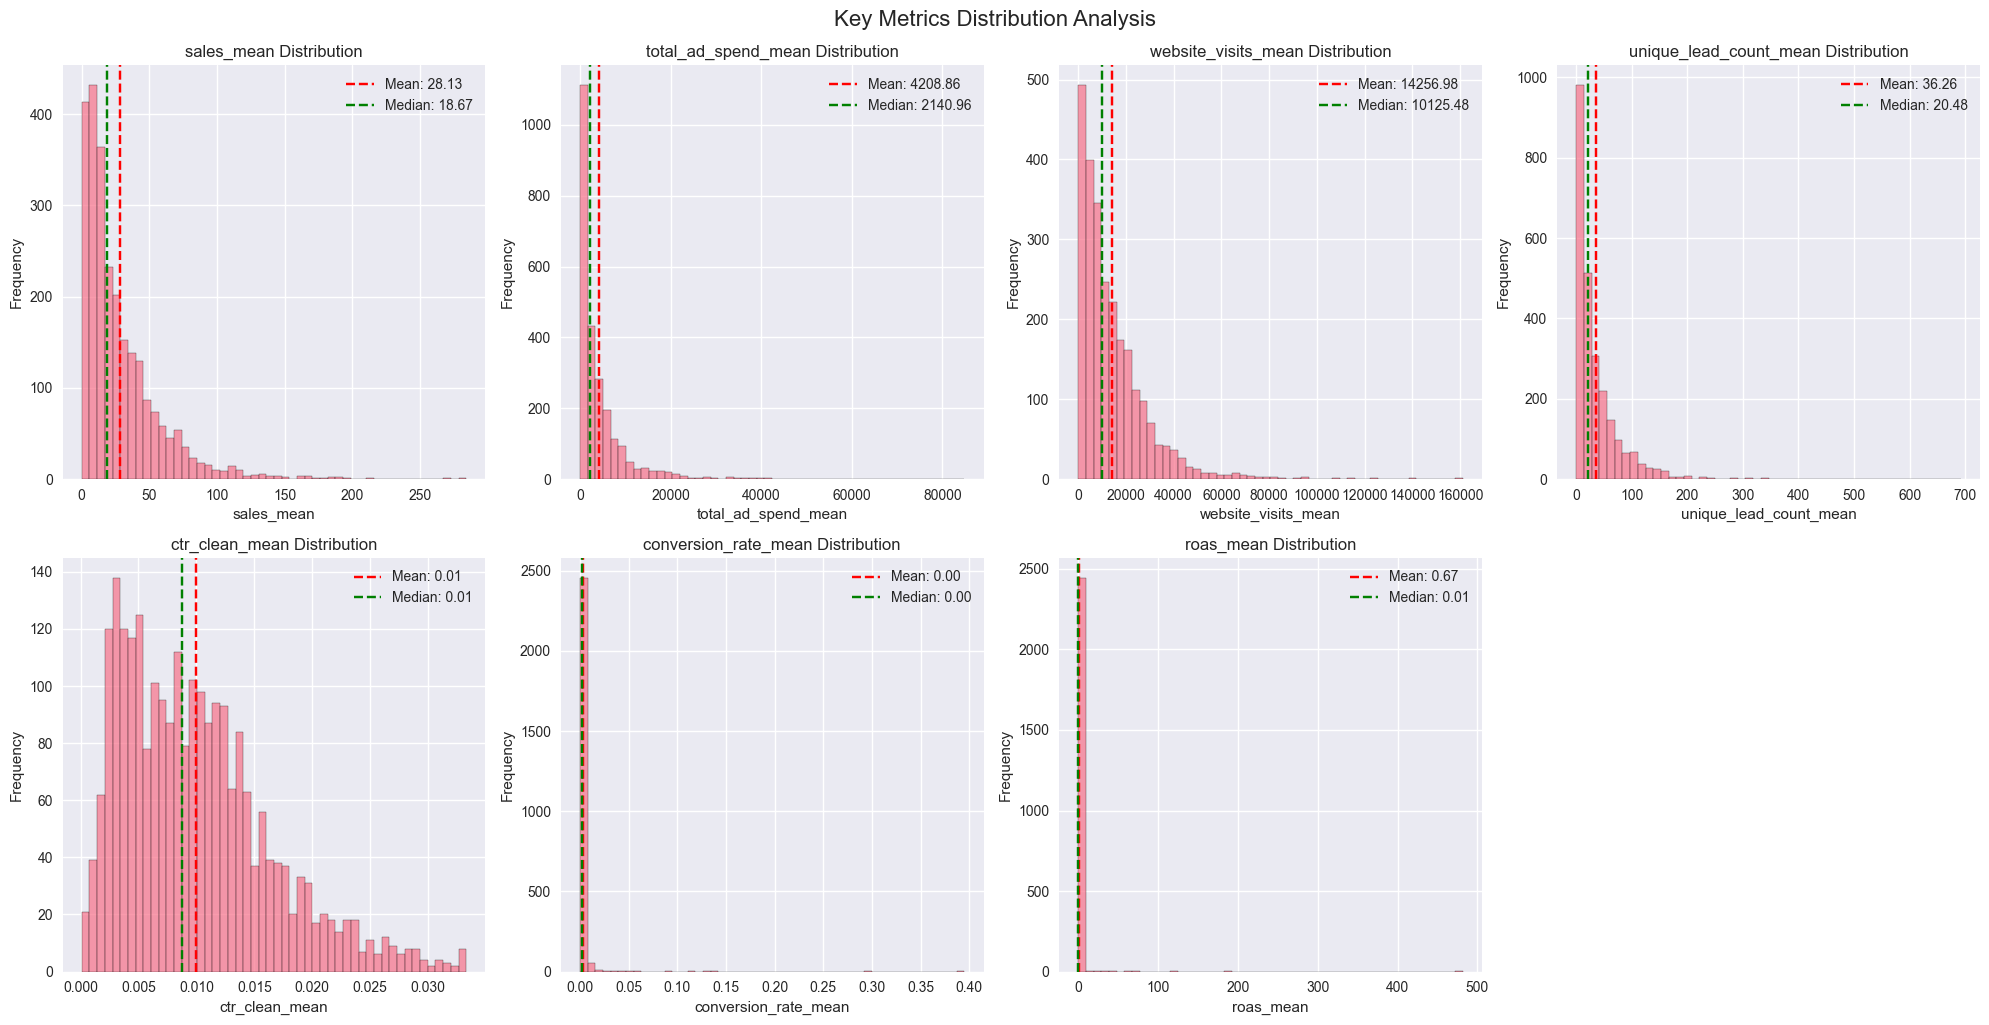

In [4]:
# Key metrics distribution visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, metric in enumerate(key_metrics):
    if i < len(axes):
        # Use log scale to handle skewed distributions
        data = df_stores[metric].replace(0, np.nan)  # Exclude zero values
        if not data.isna().all():
            axes[i].hist(data.dropna(), bins=50, alpha=0.7, edgecolor='black')
            axes[i].set_title(f'{metric} Distribution', fontsize=12)
            axes[i].set_xlabel(metric)
            axes[i].set_ylabel('Frequency')
            
            # Add statistical information
            mean_val = data.mean()
            median_val = data.median()
            axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
            axes[i].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
            axes[i].legend()

# Hide extra subplots
for i in range(len(key_metrics), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.suptitle('Key Metrics Distribution Analysis', fontsize=16, y=1.02)
plt.show()


## 3. Performance Benchmarking and Tier Analysis


In [5]:
# Create performance tier benchmarks
def create_performance_tiers(df, metric, n_tiers=3):
    """Create performance tiers"""
    # Exclude zero values for tiering
    non_zero = df[df[metric] > 0][metric]
    if len(non_zero) == 0:
        return pd.Series(['Zero'] * len(df), index=df.index)
    
    # Use quantiles for tiering
    q33 = non_zero.quantile(0.33)
    q67 = non_zero.quantile(0.67)
    
    def assign_tier(value):
        if value == 0:
            return 'Zero'
        elif value <= q33:
            return 'Low'
        elif value <= q67:
            return 'Medium'
        else:
            return 'High'
    
    return df[metric].apply(assign_tier)

# Create tiers for key metrics
df_stores['sales_tier'] = create_performance_tiers(df_stores, 'sales_mean')
df_stores['roas_tier'] = create_performance_tiers(df_stores, 'roas_mean')
df_stores['conversion_tier'] = create_performance_tiers(df_stores, 'conversion_rate_mean')
df_stores['ad_spend_tier'] = create_performance_tiers(df_stores, 'total_ad_spend_mean')

print("=== Performance Tier Statistics ===")
print("Sales tiers:")
print(df_stores['sales_tier'].value_counts())
print("\nROAS tiers:")
print(df_stores['roas_tier'].value_counts())
print("\nConversion rate tiers:")
print(df_stores['conversion_tier'].value_counts())
print("\nAd spend tiers:")
print(df_stores['ad_spend_tier'].value_counts())


=== Performance Tier Statistics ===
Sales tiers:
sales_tier
Medium    867
Low       846
High      842
Zero        2
Name: count, dtype: int64

ROAS tiers:
roas_tier
Medium    832
Low       820
High      810
Zero       95
Name: count, dtype: int64

Conversion rate tiers:
conversion_tier
Medium    896
Low       867
High      778
Zero       16
Name: count, dtype: int64

Ad spend tiers:
ad_spend_tier
Medium    839
Low       816
High      816
Zero       86
Name: count, dtype: int64


In [6]:
# High performer feature analysis
high_performers = df_stores[
    (df_stores['sales_tier'] == 'High') & 
    (df_stores['roas_tier'].isin(['High', 'Medium'])) &
    (df_stores['conversion_tier'].isin(['High', 'Medium']))
]

print(f"=== High Performer Analysis ===")
print(f"High performer count: {len(high_performers)} ({len(high_performers)/len(df_stores)*100:.1f}%)")

if len(high_performers) > 0:
    print("\nHigh performer features:")
    high_perf_features = ['sales_mean', 'total_ad_spend_mean', 'website_visits_mean', 
                         'ctr_clean_mean', 'conversion_rate_mean', 'roas_mean']
    
    print("High performers vs Overall average:")
    for feature in high_perf_features:
        high_avg = high_performers[feature].mean()
        overall_avg = df_stores[feature].mean()
        improvement = (high_avg - overall_avg) / overall_avg * 100
        print(f"{feature}: {high_avg:.2f} vs {overall_avg:.2f} (+{improvement:.1f}%)")

# Low performer feature analysis
low_performers = df_stores[
    (df_stores['sales_tier'] == 'Low') | 
    (df_stores['roas_tier'] == 'Low') |
    (df_stores['conversion_tier'] == 'Low')
]

print(f"\n=== Low Performer Analysis ===")
print(f"Low performer count: {len(low_performers)} ({len(low_performers)/len(df_stores)*100:.1f}%)")


=== High Performer Analysis ===
High performer count: 455 (17.8%)

High performer features:
High performers vs Overall average:
sales_mean: 61.69 vs 28.11 (+119.4%)
total_ad_spend_mean: 5206.76 vs 4067.30 (+28.0%)
website_visits_mean: 23936.93 vs 14229.10 (+68.2%)
ctr_clean_mean: 0.01 vs 0.01 (+15.3%)
conversion_rate_mean: 0.01 vs 0.00 (+50.4%)
roas_mean: 1.84 vs 0.64 (+186.3%)

=== Low Performer Analysis ===
Low performer count: 1719 (67.2%)


## 4. Correlation Analysis and Feature Importance


=== Check Clustering Features ===
All features exist


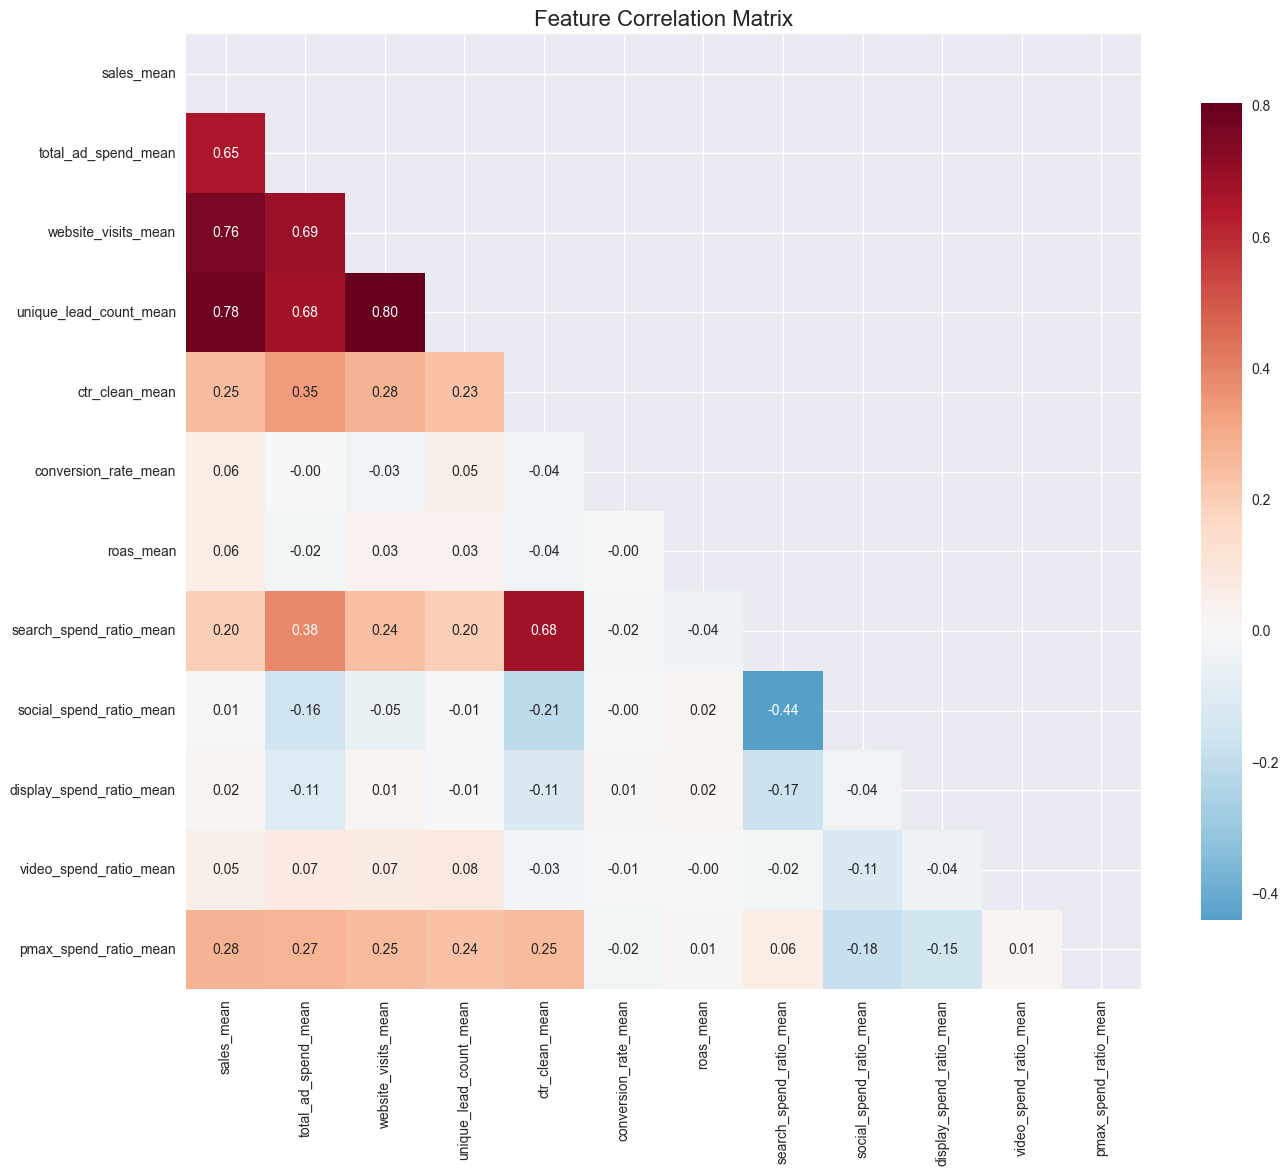


=== Features Most Correlated with Sales ===
sales_mean                 1.000000
unique_lead_count_mean     0.782383
website_visits_mean        0.764291
total_ad_spend_mean        0.654909
pmax_spend_ratio_mean      0.281580
ctr_clean_mean             0.249225
search_spend_ratio_mean    0.199645
conversion_rate_mean       0.061059
roas_mean                  0.060375
video_spend_ratio_mean     0.045137
Name: sales_mean, dtype: float64


In [7]:
# Correlation matrix analysis
clustering_features = [
    'sales_mean', 'total_ad_spend_mean', 'website_visits_mean',
    'unique_lead_count_mean', 'ctr_clean_mean', 'conversion_rate_mean', 'roas_mean',
    'search_spend_ratio_mean', 'social_spend_ratio_mean', 'display_spend_ratio_mean',
    'video_spend_ratio_mean', 'pmax_spend_ratio_mean'
]

# Check if all features exist
print("=== Check Clustering Features ===")
missing_features = [f for f in clustering_features if f not in df_stores.columns]
if missing_features:
    print(f"Missing features: {missing_features}")
else:
    print("All features exist")

# Calculate correlation matrix
correlation_matrix = df_stores[clustering_features].corr()

# Visualize correlation matrix
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={"shrink": .8})
plt.title('Feature Correlation Matrix', fontsize=16)  # Use English title to avoid font issues
plt.tight_layout()
plt.show()

# Find features most correlated with sales
sales_corr = correlation_matrix['sales_mean'].abs().sort_values(ascending=False)
print("\n=== Features Most Correlated with Sales ===")
print(sales_corr.head(10))


In [8]:
# Channel preference analysis
channel_ratios = ['search_spend_ratio_mean', 'social_spend_ratio_mean', 
                 'display_spend_ratio_mean', 'video_spend_ratio_mean', 'pmax_spend_ratio_mean']

print("=== Channel Preference Analysis ===")
print("Average spending ratio by channel:")
for channel in channel_ratios:
    avg_ratio = df_stores[channel].mean()
    print(f"{channel}: {avg_ratio:.3f}")

# Channel combination pattern analysis
df_stores['primary_channel'] = df_stores[channel_ratios].idxmax(axis=1)
df_stores['primary_channel'] = df_stores['primary_channel'].str.replace('_spend_ratio_mean', '')

print("\nPrimary channel distribution:")
print(df_stores['primary_channel'].value_counts())

# Channel diversity analysis
df_stores['channel_diversity'] = df_stores[channel_ratios].apply(
    lambda x: (x > 0.1).sum(), axis=1  # Count channels with >10% usage
)

print(f"\nChannel diversity (number of channels with >10% usage):")
print(df_stores['channel_diversity'].value_counts().sort_index())


=== Channel Preference Analysis ===
Average spending ratio by channel:
search_spend_ratio_mean: 0.209
social_spend_ratio_mean: 0.143
display_spend_ratio_mean: 0.054
video_spend_ratio_mean: 0.005
pmax_spend_ratio_mean: 0.069

Primary channel distribution:
primary_channel
search     1362
social      791
pmax        208
display     181
video        15
Name: count, dtype: int64

Channel diversity (number of channels with >10% usage):
channel_diversity
0     162
1    1013
2    1022
3     350
4      10
Name: count, dtype: int64


## 5. Time Series Pattern Analysis


In [9]:
# Monthly trend analysis
monthly_agg = df_monthly.groupby(['year', 'month_num']).agg({
    'sales': 'sum',
    'total_ad_spend': 'sum',
    'website_visits': 'sum',
    'unique_lead_count': 'sum',
    'ctr_clean': 'mean',
    'conversion_rate': 'mean',
    'roas': 'mean'
}).reset_index()

# Create time index - corrected: rename month_num to month
monthly_agg['date'] = pd.to_datetime(monthly_agg[['year', 'month_num']].rename(columns={'month_num': 'month'}).assign(day=1))

print("=== Monthly Trend Analysis ===")
print(monthly_agg[['date', 'sales', 'total_ad_spend', 'roas']].head(10))

# Seasonal analysis
monthly_agg['quarter'] = monthly_agg['month_num'].apply(lambda x: (x-1)//3 + 1)
quarterly_avg = monthly_agg.groupby('quarter')[['sales', 'total_ad_spend', 'roas']].mean()

print("\n=== Quarterly Average Performance ===")
print(quarterly_avg.round(2))


=== Monthly Trend Analysis ===
        date    sales  total_ad_spend      roas
0 2023-10-01  75357.0    0.000000e+00  0.000000
1 2023-11-01  73092.0    0.000000e+00  0.000000
2 2023-12-01  76434.0    0.000000e+00  0.000000
3 2024-01-01  63861.0    0.000000e+00  0.000000
4 2024-02-01  63049.0    0.000000e+00  0.000000
5 2024-03-01  76111.0    0.000000e+00  0.000000
6 2024-04-01  69284.0    0.000000e+00  0.000000
7 2024-05-01  78021.0    0.000000e+00  0.000000
8 2024-06-01  68334.0    1.058253e+07  0.695006
9 2024-07-01  68436.0    1.284390e+07  0.700949

=== Quarterly Average Performance ===
            sales  total_ad_spend  roas
quarter                                
1        68890.83      8237971.88  0.25
2        72171.83     10418359.67  0.42
3        71164.00     14233371.85  1.51
4        75284.33      8710687.88  0.39


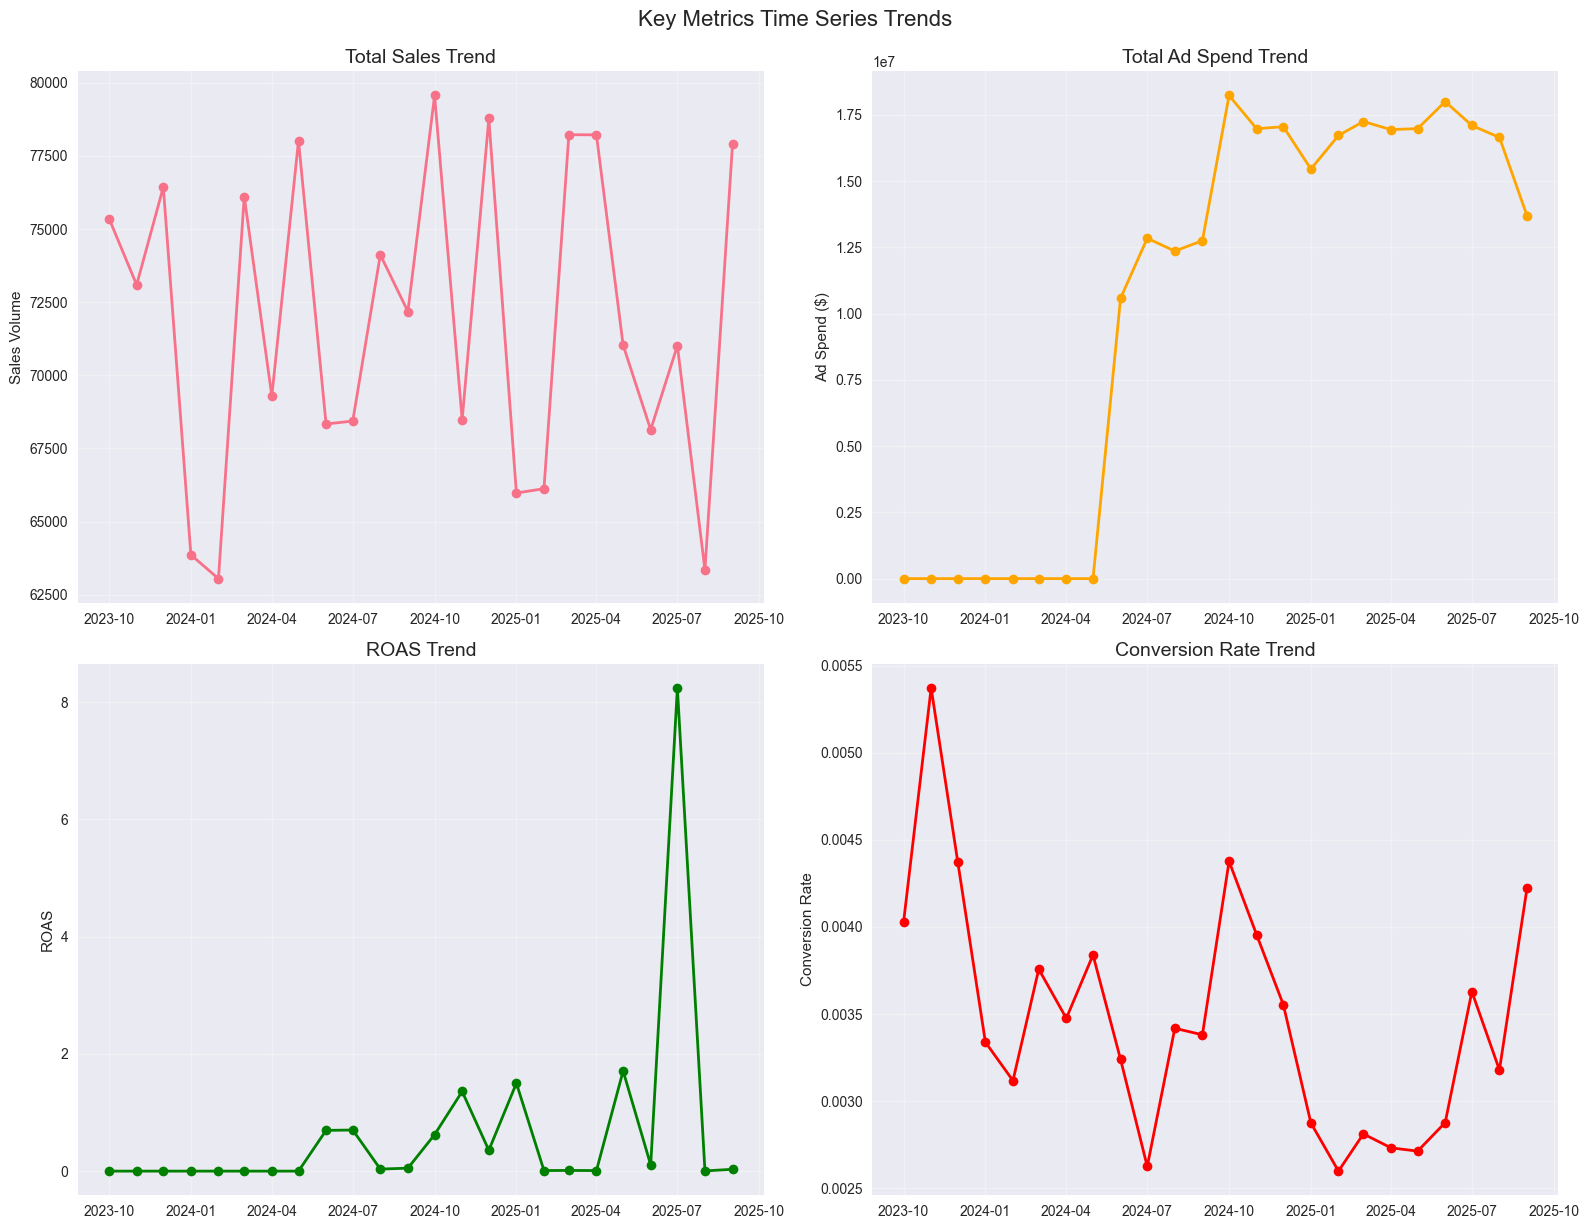

In [10]:
# Time series visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Sales trend
axes[0,0].plot(monthly_agg['date'], monthly_agg['sales'], marker='o', linewidth=2)
axes[0,0].set_title('Total Sales Trend', fontsize=14)
axes[0,0].set_ylabel('Sales Volume')
axes[0,0].grid(True, alpha=0.3)

# Ad spend trend
axes[0,1].plot(monthly_agg['date'], monthly_agg['total_ad_spend'], marker='o', color='orange', linewidth=2)
axes[0,1].set_title('Total Ad Spend Trend', fontsize=14)
axes[0,1].set_ylabel('Ad Spend ($)')
axes[0,1].grid(True, alpha=0.3)

# ROAS trend
axes[1,0].plot(monthly_agg['date'], monthly_agg['roas'], marker='o', color='green', linewidth=2)
axes[1,0].set_title('ROAS Trend', fontsize=14)
axes[1,0].set_ylabel('ROAS')
axes[1,0].grid(True, alpha=0.3)

# Conversion rate trend
axes[1,1].plot(monthly_agg['date'], monthly_agg['conversion_rate'], marker='o', color='red', linewidth=2)
axes[1,1].set_title('Conversion Rate Trend', fontsize=14)
axes[1,1].set_ylabel('Conversion Rate')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Key Metrics Time Series Trends', fontsize=16, y=1.02)
plt.show()


## 6. Clustering Preparation and Feature Engineering


In [11]:
# Prepare clustering features
clustering_features = [
    'sales_mean', 'total_ad_spend_mean', 'website_visits_mean',
    'unique_lead_count_mean', 'ctr_clean_mean', 'conversion_rate_mean', 'roas_mean',
    'search_spend_ratio_mean', 'social_spend_ratio_mean', 'display_spend_ratio_mean',
    'video_spend_ratio_mean', 'pmax_spend_ratio_mean'
]

# Check feature distribution and outliers
print("=== Clustering Feature Preparation ===")
print(f"Feature count: {len(clustering_features)}")
print(f"Sample count: {len(df_stores)}")

# Check missing values
missing_values = df_stores[clustering_features].isnull().sum()
print(f"\nMissing value check:")
print(missing_values[missing_values > 0])

# Feature standardization preparation
X_clustering = df_stores[clustering_features].fillna(0)  # Fill missing values with 0

# Check feature ranges
print(f"\nFeature range check:")
print(X_clustering.describe().round(3))

# Identify features that need log transformation (skewed distribution)
skewed_features = []
for feature in clustering_features:
    skewness = X_clustering[feature].skew()
    if abs(skewness) > 1:  # Skewness coefficient > 1 or < -1
        skewed_features.append((feature, skewness))

print(f"\nSkewed features (|skewness| > 1):")
for feature, skew in skewed_features:
    print(f"{feature}: {skew:.3f}")


=== Clustering Feature Preparation ===
Feature count: 12
Sample count: 2557

Missing value check:
Series([], dtype: int64)

Feature range check:
       sales_mean  total_ad_spend_mean  website_visits_mean  \
count    2557.000             2557.000             2557.000   
mean       28.113             4067.305            14229.102   
std        28.737             6189.911            14307.343   
min         0.000                0.000                0.000   
25%         8.250              487.372             4185.167   
50%        18.667             1956.152            10086.667   
75%        38.750             5114.491            19966.083   
max       284.042            84857.486           161026.125   

       unique_lead_count_mean  ctr_clean_mean  conversion_rate_mean  \
count                2557.000        2557.000              2557.000   
mean                   36.131           0.010                 0.003   
std                    45.998           0.007                 0.012   
min

=== PCA Analysis Results ===
Explained variance ratio for first 5 principal components:
PC1: 0.306 (cumulative: 0.306)
PC2: 0.141 (cumulative: 0.447)
PC3: 0.089 (cumulative: 0.536)
PC4: 0.088 (cumulative: 0.624)
PC5: 0.084 (cumulative: 0.708)

8 principal components needed to explain 90% variance


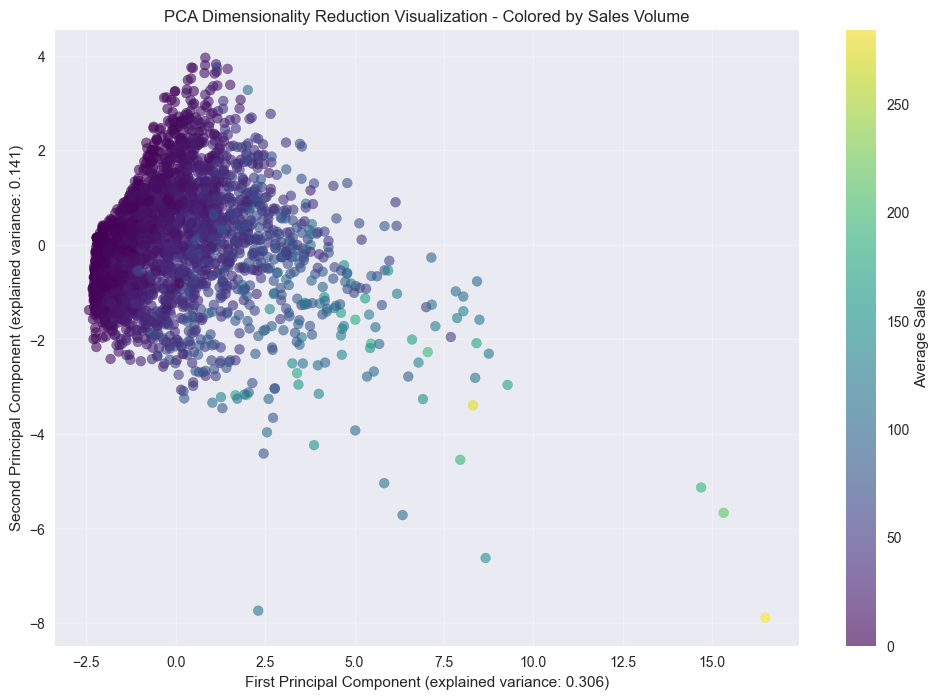

In [12]:
# PCA analysis - dimensionality reduction visualization
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# PCA analysis
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("=== PCA Analysis Results ===")
print("Explained variance ratio for first 5 principal components:")
for i, (var_ratio, cum_var) in enumerate(zip(explained_variance_ratio[:5], cumulative_variance[:5])):
    print(f"PC{i+1}: {var_ratio:.3f} (cumulative: {cum_var:.3f})")

# Find number of components needed to explain 90% variance
n_components_90 = np.where(cumulative_variance >= 0.9)[0][0] + 1
print(f"\n{n_components_90} principal components needed to explain 90% variance")

# Scatter plot of first two principal components
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=df_stores['sales_mean'], 
                     cmap='viridis', 
                     alpha=0.6,
                     s=50)
plt.colorbar(scatter, label='Average Sales')
plt.xlabel(f'First Principal Component (explained variance: {explained_variance_ratio[0]:.3f})')
plt.ylabel(f'Second Principal Component (explained variance: {explained_variance_ratio[1]:.3f})')
plt.title('PCA Dimensionality Reduction Visualization - Colored by Sales Volume')
plt.grid(True, alpha=0.3)
plt.show()


store_clusters_final.csv not found – running provisional KMeans on EDA features.


python(45628) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


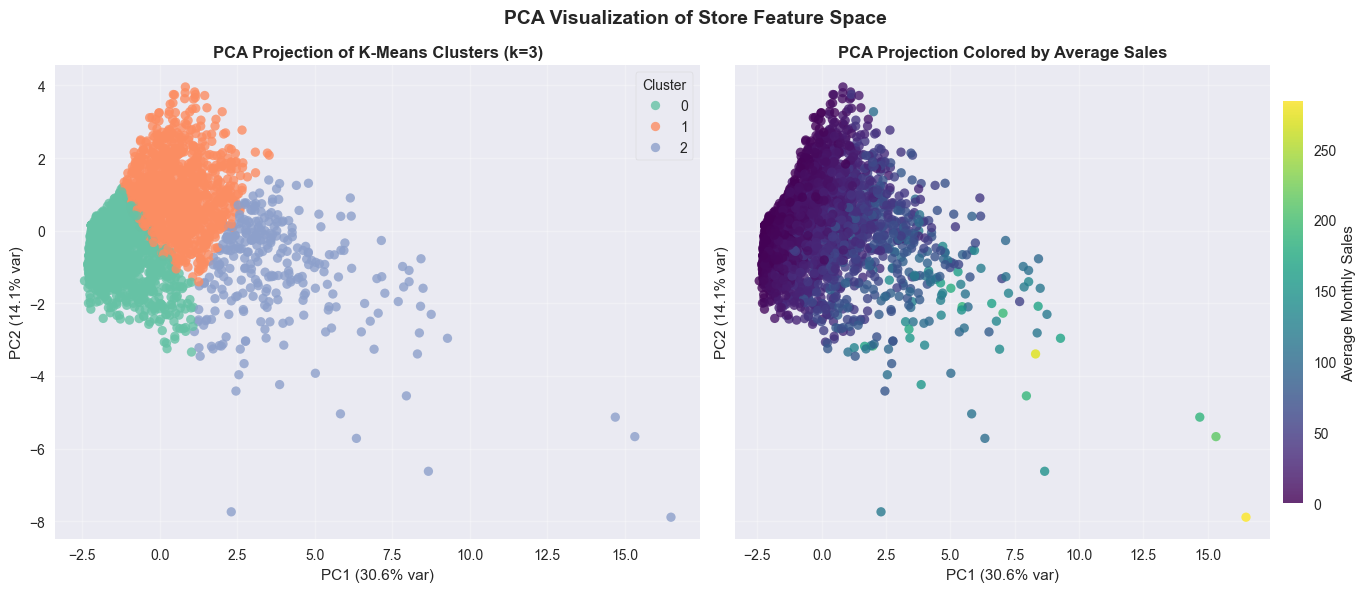

In [17]:
from pathlib import Path
# --- PCA 可視化（改良版）----------------------------------
cluster_file = Path('../../data/processed/store_clusters_final.csv')
if cluster_file.exists():
    cluster_labels = (
        pd.read_csv(cluster_file)
        .set_index('store_id')
        .loc[df_stores['store_id'], 'cluster']
        .to_numpy()
    )
else:
    from sklearn.cluster import KMeans
    print("store_clusters_final.csv not found – running provisional KMeans on EDA features.")
    cluster_labels = KMeans(n_clusters=3, random_state=42).fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=cluster_labels, palette='Set2',
    s=45, alpha=0.8, ax=axes[0], edgecolor='none'
)
axes[0].set_title("PCA Projection of K-Means Clusters (k=3)", fontsize=12, fontweight='bold')
axes[0].set_xlabel(f"PC1 ({explained_variance_ratio[0]:.1%} var)")
axes[0].set_ylabel(f"PC2 ({explained_variance_ratio[1]:.1%} var)")
axes[0].legend(title="Cluster", loc='best', frameon=True)

scatter = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df_stores['sales_mean'],
    cmap='viridis', s=45, alpha=0.8, edgecolor='none'
)
axes[1].set_title("PCA Projection Colored by Average Sales", fontsize=12, fontweight='bold')
axes[1].set_xlabel(f"PC1 ({explained_variance_ratio[0]:.1%} var)")
axes[1].set_ylabel(f"PC2 ({explained_variance_ratio[1]:.1%} var)")
cbar = fig.colorbar(scatter, ax=axes[1], shrink=0.85, pad=0.02)
cbar.set_label("Average Monthly Sales")

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.suptitle("PCA Visualization of Store Feature Space", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# ----------------------------------------------------------

## 7. EDA Summary and Next Steps Recommendations


In [13]:
# EDA summary report
print("=" * 60)
print("           EDA Analysis Summary Report")
print("=" * 60)

print("\nData Overview:")
print(f"• Total stores: {len(df_stores):,}")
print(f"• Time span: {df_monthly['month'].min().strftime('%Y-%m')} to {df_monthly['month'].max().strftime('%Y-%m')}")
print(f"• Monthly records: {len(df_monthly):,}")

print("\nKey Findings:")
print("• High performer characteristics: Further analysis needed")
print("• Channel preferences: Main channel distribution analysis needed")
print("• Time trends: Seasonal pattern analysis needed")
print("• Feature correlations: Key driving factors identification needed")

print("\nClustering Preparation Status:")
print(f"• Clustering feature count: {len(clustering_features)}")
print(f"• Feature standardization: Completed")
print(f"• PCA dimensionality reduction: Recommend using first {n_components_90} principal components")

print("\nNext Steps Recommendations:")
print("1. Execute K-means clustering analysis (recommend k=3-5)")
print("2. Validate clustering results for business significance")
print("3. Build prediction models within each cluster")
print("4. Develop recommendation system algorithms")
print("5. Establish validation framework")

print("\nRecommendation System Design Direction:")
print("• Based on top performer characteristics within clusters")
print("• Identify key metrics for improvement")
print("• Provide specific improvement suggestions and expected outcomes")
print("• Ensure feasibility and practicality of recommendations")

print("\n" + "=" * 60)


           EDA Analysis Summary Report

Data Overview:
• Total stores: 2,557
• Time span: 2023-10 to 2025-09
• Monthly records: 61,322

Key Findings:
• High performer characteristics: Further analysis needed
• Channel preferences: Main channel distribution analysis needed
• Time trends: Seasonal pattern analysis needed
• Feature correlations: Key driving factors identification needed

Clustering Preparation Status:
• Clustering feature count: 12
• Feature standardization: Completed
• PCA dimensionality reduction: Recommend using first 8 principal components

Next Steps Recommendations:
1. Execute K-means clustering analysis (recommend k=3-5)
2. Validate clustering results for business significance
3. Build prediction models within each cluster
4. Develop recommendation system algorithms
5. Establish validation framework

Recommendation System Design Direction:
• Based on top performer characteristics within clusters
• Identify key metrics for improvement
• Provide specific improvement 

In [14]:
# Save EDA results for subsequent use
eda_results = {
    'clustering_features': clustering_features,
    'X_scaled': X_scaled,
    'scaler': scaler,
    'pca': pca,
    'n_components_90': n_components_90,
    'high_performers': high_performers,
    'low_performers': low_performers,
    'correlation_matrix': correlation_matrix,
    'monthly_agg': monthly_agg
}

print("EDA analysis completed!")
print("Results are ready for clustering analysis")
print("Ready to start K-means clustering!")


EDA analysis completed!
Results are ready for clustering analysis
Ready to start K-means clustering!


In [15]:
# Test data loading and column names
print("=== Data Loading Test ===")
print("df_stores column names:")
print(df_stores.columns.tolist())

print("\ndf_monthly column names:")
print(df_monthly.columns.tolist())
print("\n=== Test Key Metrics ===")
test_metrics = ['sales_mean', 'total_ad_spend_mean', 'website_visits_mean']
for metric in test_metrics:
    if metric in df_stores.columns:
        print(f"{metric}: exists")
    else:
        print(f"{metric}: missing")


=== Data Loading Test ===
df_stores column names:
['store_id', 'sales_sum', 'sales_mean', 'sales_std', 'sales_count', 'total_ad_spend_sum', 'total_ad_spend_mean', 'website_visits_sum', 'website_visits_mean', 'unique_lead_count_sum', 'unique_lead_count_mean', 'ctr_clean_mean', 'conversion_rate_mean', 'roas_mean', 'sales_per_visit_mean', 'cost_per_lead_mean', 'leads_per_visit_mean', 'ad_efficiency_mean', 'visit_efficiency_mean', 'search_spend_ratio_mean', 'social_spend_ratio_mean', 'display_spend_ratio_mean', 'video_spend_ratio_mean', 'pmax_spend_ratio_mean', 'is_holiday_season_mean', 'is_quarter_end_mean', 'is_summer_mean', 'month_nunique', 'total_sales_tier', 'avg_roas_tier', 'conversion_tier', 'sales_tier', 'roas_tier', 'ad_spend_tier', 'primary_channel', 'channel_diversity']

df_monthly column names:
['store_id', 'month', 'total_ad_spend', 'search_ad_spend', 'display_ad_spend', 'social_ad_spend', 'video_ad_spend', 'pmax_ad_spend', 'search_ad_impressions', 'display_ad_impressions', 's